<a href="https://colab.research.google.com/github/SDD1Leo/House-Prices-Prediction/blob/main/House_Prices_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!export KAGGLE_API_TOKEN=KGAT_8a4028bbfb6942406fda97a6618be6fd

In [5]:
!kaggle kernels pull ahmedmahmoud16/california-housing-prices

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_train = pd.read_csv("/content/sample_data/california_housing_train.csv")

In [3]:
data_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


In [4]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [5]:
x_train = data_train.drop(['median_house_value'], axis=1)
y_train = data_train['median_house_value']

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

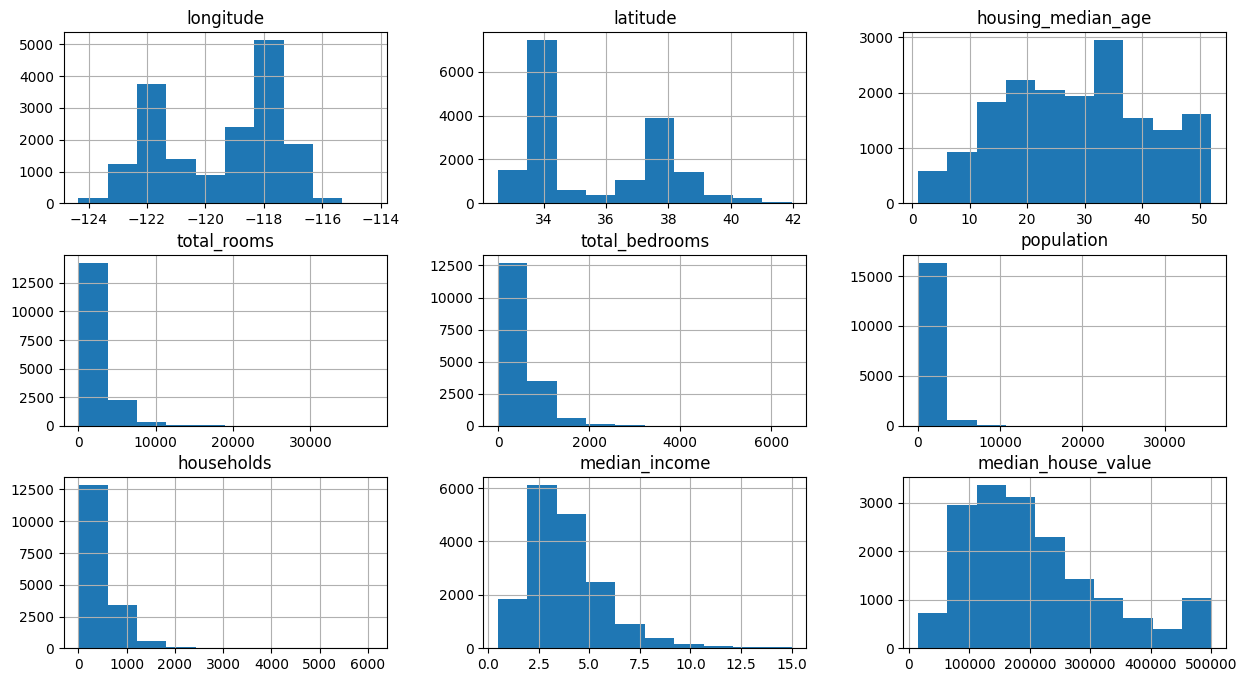

In [6]:
data_train.hist(figsize=(15,8))

<Axes: >

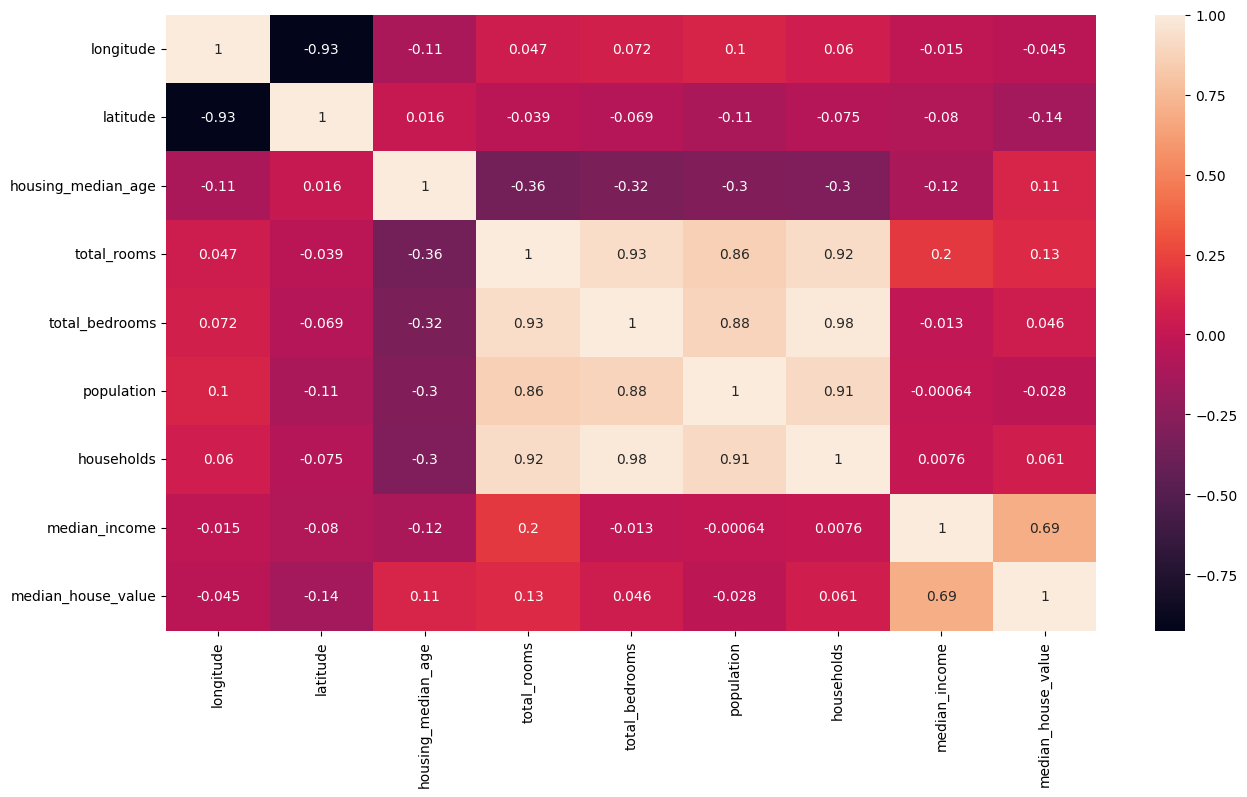

In [7]:
plt.figure(figsize=(15,8))
sns.heatmap(data_train.corr(), annot=True)

<Axes: xlabel='longitude', ylabel='latitude'>

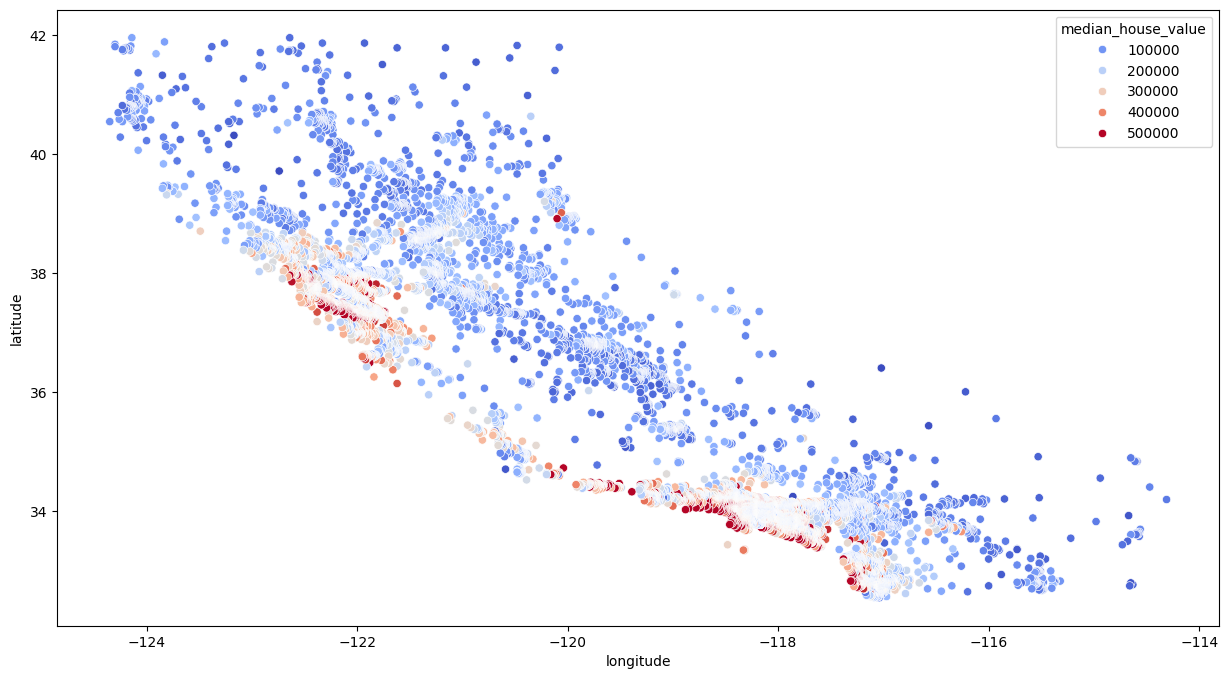

In [8]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='longitude', y='latitude', data=data_train, hue='median_house_value', palette="coolwarm")

In [9]:
data_train['bedroom_ratio'] = data_train['total_bedrooms'] / data_train['total_rooms']
data_train['household_rooms'] = data_train['total_rooms'] / data_train['households']

<Axes: >

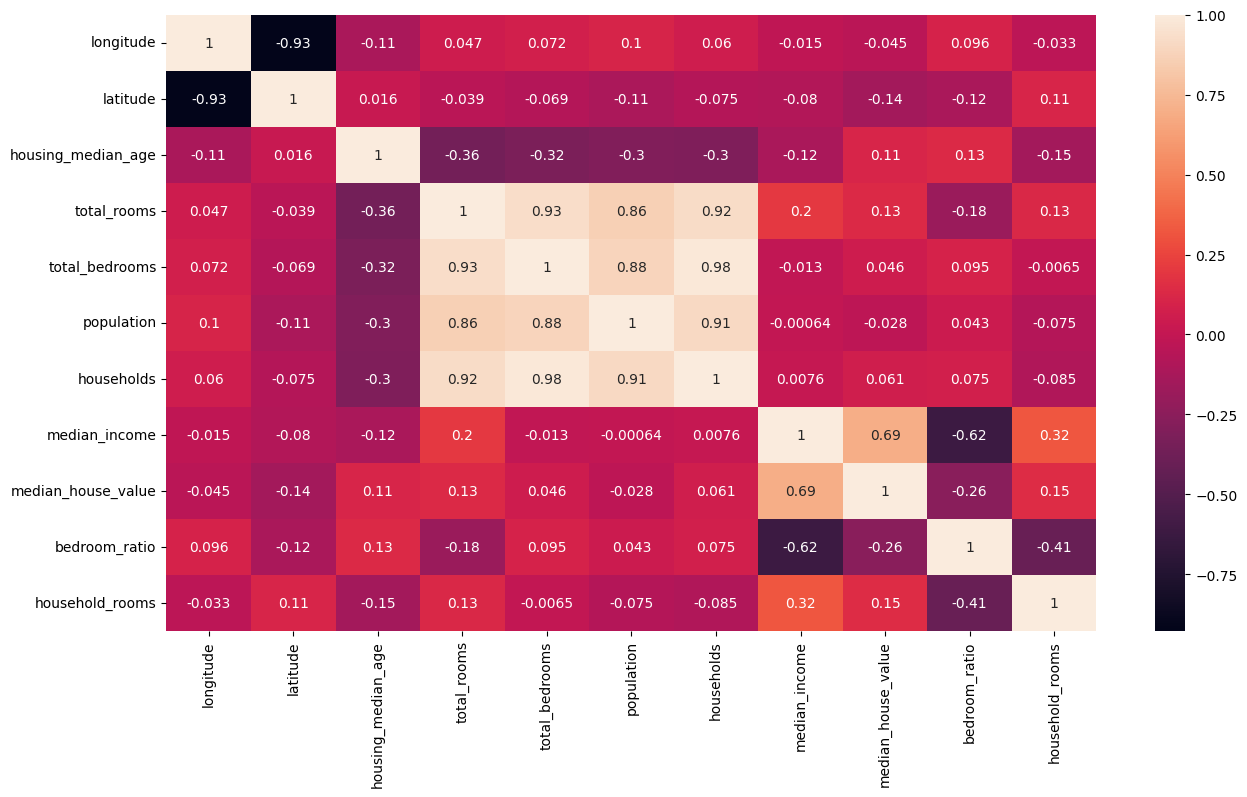

In [10]:
plt.figure(figsize=(15,8))
sns.heatmap(data_train.corr(), annot=True)

In [11]:
x_train = data_train.drop(['median_house_value'], axis=1)
y_train = data_train['median_house_value']

In [12]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

reg.fit(x_train,y_train)

LinearRegression()

In [13]:
data_test = pd.read_csv("/content/sample_data/california_housing_test.csv")

In [14]:
data_test['bedroom_ratio'] = data_test['total_bedrooms'] / data_test['total_rooms']
data_test['household_rooms'] = data_test['total_rooms'] / data_test['households']

In [15]:
x_test = data_test.drop(['median_house_value'], axis=1)
y_test = data_test['median_house_value']

<Axes: >

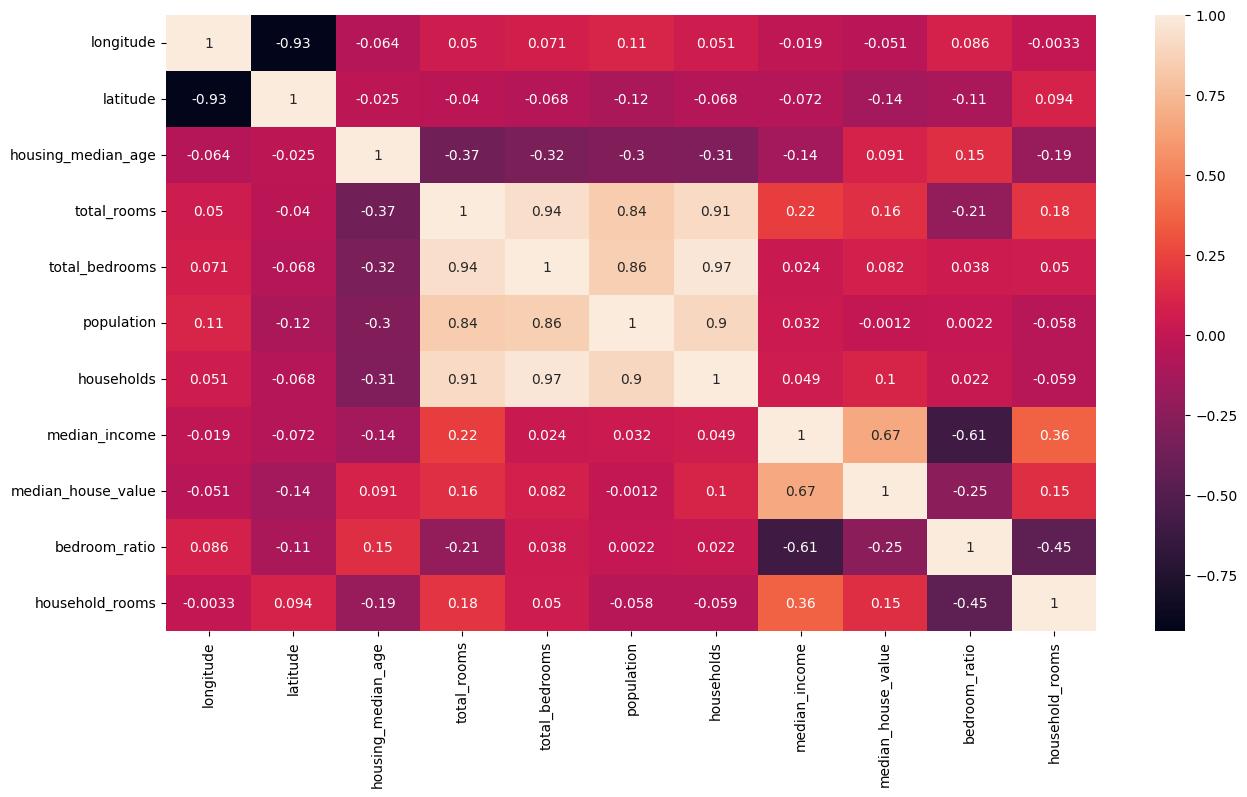

In [16]:
plt.figure(figsize=(15,8))
sns.heatmap(data_test.corr(), annot=True)

In [17]:
reg.score(x_test,y_test)

0.628561787441495

In [18]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()

forest.fit(x_train,y_train)

RandomForestRegressor()

In [19]:
forest.score(x_test,y_test)

0.797766835517016

In [20]:
# Perform inference on the first 5 rows of the test set
predictions = forest.predict(x_test.head())

# Create a comparison table
inference_results = pd.DataFrame({
    'Actual Value': y_test.head().values,
    'Predicted Value': predictions
})

display(inference_results)

,Actual Value,Predicted Value
0,344700.0,404876.11
1,176500.0,221751.00
2,270500.0,274295.03
3,330000.0,353078.22
4,81700.0,75443.00


In [26]:
# @title Housing Price Prediction Tool
# @markdown Enter the housing details below to get a price prediction.

longitude = -122.23 # @param {type:"number"}
latitude = 37.88 # @param {type:"number"}
housing_median_age = 41 # @param {type:"slider", min:1, max:52, step:1}
total_rooms = 880 # @param {type:"number"}
total_bedrooms = 129 # @param {type:"number"}
population = 322 # @param {type:"number"}
households = 126 # @param {type:"number"}
median_income = 8.3252 # @param {type:"number"}

# Calculate engineered features
bedroom_ratio = total_bedrooms / total_rooms
household_rooms = total_rooms / households

# Create a dataframe for the input
user_input = pd.DataFrame([[longitude, latitude, housing_median_age, total_rooms,
                           total_bedrooms, population, households, median_income,
                           bedroom_ratio, household_rooms]],
                         columns=['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                                  'total_bedrooms', 'population', 'households', 'median_income',
                                  'bedroom_ratio', 'household_rooms'])

# Prediction using the forest model
prediction = forest.predict(user_input)[0]

print(f"Predicted Median House Value: ${prediction:,.2f}")

Predicted Median House Value: $436,517.05
